### Scrapy
- 웹 크롤링 및 스크래핑 프레임워크
    - 크롤링, 데이터 추출, 데이터 처리 및 저장 등 전체 웹 스크래핑 프로세스를 지원
- 비동기 처리를 지원하여 빠르고 효율적인 웹크롤링 가능
- XPath 및 CSS 선택자를 사용하여 복잡한 웹 페이지에서 원하는 데이터 추출 용이
    - CSS 선택자: 특정 HTML 요소를 선택하기 위한 패턴 (예: div, .class, #id, h1::text 등)
    ```
    response.css('css_selector')
    # 특정 태그
    response.css('title')
    # 클래스 선택
    response.css('.class-name')
    # ID 선택
    response.css('#element-id')
    # 속성 추출
    response.css('img::attr(src)')
    # 텍스트 추출
    response.css('h1::text')
    # 특정문자열
    response.css('a[href*="example"]')
    ```
    - Xpath : XML 문서나 HTML 문서에서 특정 요소를 찾기 위한 언어 표현식 (Scrapy 선택자의 기본 메커니즘)
    ```
    response.xpath('<XPath 표현식>')
    # 모든 태그
    response.xpath('//title')
    # 특정 경로의 모든 태그
    response.xpath('/html/body/div')
    # 속성 추출
    response.xpath('//img/@src')
    # 텍스트 추출
    response.xpath('//h1/text()')
    # 특정 문자열 추출
    response.xpath('//a[contains(@href, 'example')]')
    ```
- 웹사이트에서 대량의 데이터를 수집하고자 할 때 유용

비동기 처리 : 1, 2, 3, 4, 5 순서로 진행될 때<br>
앞의 순서가 끝나지 않아도 진행되는 병렬형태의 진행<br>
body>div.notebook-vertical -> response.css<br>
/html/body/div[7] : xpath로 div의 7번째를 가져옴

#### scrapy 아키텍처

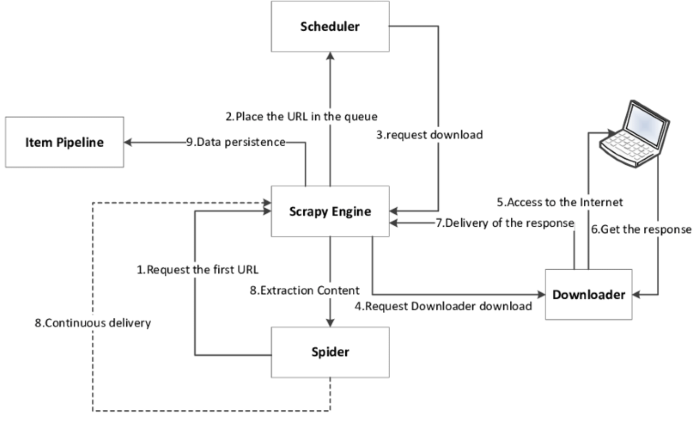

#### scrapy 동작과정
- Spider 시작: 사용자가 정의한 Spider에서 시작 URL 또는 요청 생성
- Scheduler 등록: 생성된 요청을 스케줄러가 큐에 추가
- Downloader 요청 처리: 큐에서 요청을 꺼내 HTTP 요청 실행
- Response 처리: 받은 응답을 Spider로 전달하여 데이터 추출
- Item Pipeline: 추출된 데이터를 저장하거나 가공
- 재요청: Spider에서 새로운 요청 생성, 다시 스케줄러로 전달
- 작업 종료: 요청이 없으면 종료

##### **return vs. yield**
- return: 함수 실행이 종료되고 값을 반환
- yield: 값을 반환하면서 함수의 실행 상태를 저장(중단)하고, 필요할 때 다시 실행을 재개
    - scrapy에서는 yield를 사용해 새로운 요청(Request)을 스케줄러에 전달하거나 크롤링한 데이터를 Item Pipeline으로 전달할 때 사용

##### **get() vs. getall()**
- get(): 첫 번째 매칭되는 항목을 반환, 없으면 None을 반환
- getall(): 모든 매칭되는 항목을 리스트로 반환
    - scrapy에서는 링크를 추출해 새 요청 생성할 때 주로 사용

In [2]:
# return과 yield 차이
def normal_function():
    return 1
    return 2  # 실행되지 않음

def generator_function():
    yield 1
    yield 2

print("normal1", normal_function())
print("normal2", normal_function())  # 출력: 1

gen = generator_function()
print(next(gen))  # 출력: 1
print(next(gen))  # 출력: 2

normal1 1
normal2 1
1
2


*****코랩은 꼭 한번 할 때마다 런타임 중지하고 다시 밑에 두개의 코드 블럭을 실행 후 해주어야함!!!!!!!!!!


In [1]:
%%capture
# scrapy 설치
!pip install scrapy

In [2]:
# scrapy, CrawlerProcess 모듈 불러오기
import scrapy
from scrapy.crawler import CrawlerProcess

In [5]:
# ExampleSpider 정의
class ExampleSpider(scrapy.Spider): #상속받아 만듬
    name = 'example'
    start_urls = ['https://likelion.net/']

    def parse(self, response):
        title = response.css('title::text').get()
        yield {'Title': title}  # 값을 반환하면서 함수의 실행 상태를 저장(중단)하고, 필요할 때 다시 실행을 재개

# Scrapy 크롤러 실행
process = CrawlerProcess(settings={
    "USER_AGENT": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "FEEDS": {"output.csv": {"format": "csv", "encoding": "utf-8"}}, #저장하는 곳과 방식 지정
    "DOWNLOAD_DELAY": 1.0,  # 요청 간 1초 딜레이 # 한 번에 다 받아올 때 과부하 올 수 있기 때문
})
process.crawl(ExampleSpider) #ExampleSpider크롤링
process.start()

# Scrapy 크롤러 실행 ## 위의 프로세스 사용은 코랩에서 사용 밑에는 전체 프로젝트에서 사용
# scrapy crawl example # name을 example로 했기 때문에

INFO:scrapy.utils.log:Scrapy 2.12.0 started (bot: scrapybot)
2025-02-03 01:24:11 [scrapy.utils.log] INFO: Scrapy 2.12.0 started (bot: scrapybot)
INFO:scrapy.utils.log:Versions: lxml 5.3.0.0, libxml2 2.12.9, cssselect 1.2.0, parsel 1.10.0, w3lib 2.3.1, Twisted 24.11.0, Python 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0], pyOpenSSL 24.2.1 (OpenSSL 3.3.2 3 Sep 2024), cryptography 43.0.3, Platform Linux-6.1.85+-x86_64-with-glibc2.35
2025-02-03 01:24:11 [scrapy.utils.log] INFO: Versions: lxml 5.3.0.0, libxml2 2.12.9, cssselect 1.2.0, parsel 1.10.0, w3lib 2.3.1, Twisted 24.11.0, Python 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0], pyOpenSSL 24.2.1 (OpenSSL 3.3.2 3 Sep 2024), cryptography 43.0.3, Platform Linux-6.1.85+-x86_64-with-glibc2.35
INFO:scrapy.addons:Enabled addons:
[]
2025-02-03 01:24:11 [scrapy.addons] INFO: Enabled addons:
[]
DEBUG:scrapy.utils.log:Using reactor: twisted.internet.epollreactor.EPollReactor
2025-02-03 01:24:11 [scrapy.utils.log] DEBUG: Using reactor: twi

#### scrapy 사용 예제
CGV의 영화 정보

In [4]:
# Movie 정보 item 클래스 정의
class MovieItem(scrapy.Item):
    title = scrapy.Field()          #영화제목
    poster = scrapy.Field()         #포스터이미지(링크)
    percent = scrapy.Field()        #예매율
    director = scrapy.Field()       #감독
    actors = scrapy.Field()         #배우
    genre = scrapy.Field()          #장르
    level = scrapy.Field()          #관람등급
    duration = scrapy.Field()       #러닝타임
    country = scrapy.Field()        #제작국가
    releasedate = scrapy.Field()    #개봉일
    story = scrapy.Field()          #영화스토리
    comment = scrapy.Field()        #관람평요약

In [5]:
# MovieSpider 클래스 정의
class MovieSpider(scrapy.Spider):
	# 스파이더 이름(실행)
    name = "movie"

    # 뮤비차트 페이지 정보 획득
    def start_requests(self):
        url = "http://www.cgv.co.kr/movies/?lt=1&ft=0"
        yield scrapy.Request(url, self.parse_start)

    # 영화 상세 페이지 url로 request
    def parse_start(self, response):
        cgv_link = 'http://www.cgv.co.kr'
        movie_links = response.css('div.sect-movie-chart a::attr(href)').getall()
        for m in movie_links:
            url = cgv_link + m
            yield scrapy.Request(url, self.parse_items)

    # 영화 상세 페이지에 있는 정보 크롤링
    def parse_items(self, response):
        item = MovieItem()
        item['title'] = response.xpath('//*[@id="select_main"]/div[1]/div[2]/div[1]/strong/text()').get()
        item['poster'] = response.xpath('//*[@id="select_main"]/div[1]/div[1]/a/span/img/@src').get()
        item['percent'] = response.xpath('//*[@id="select_main"]/div[1]/div[2]/div[2]/strong/span/text()').get()
        item['director'] = response.xpath('//*[@id="select_main"]/div[1]/div[2]/div[3]/dl/dd[1]/a/text()').get()
        item['actors'] = response.xpath('//*[@id="select_main"]/div[1]/div[2]/div[3]/dl/dd[3]/a/text()').getall() #배우가 여러명
        item['genre'] = response.xpath('//*[@id="select_main"]/div[1]/div[2]/div[3]/dl/dt[3]/text()').get()
        item['level'], item['duration'], item['country'] = response.xpath('//*[@id="select_main"]/div[1]/div[2]/div[3]/dl/dd[5]/text()').get().strip().split(',')
        item['releasedate'] = response.xpath('//*[@id="select_main"]/div[1]/div[2]/div[3]/dl/dd[6]/text()').get()
        item['story'] = response.xpath('//*[@id="menu"]/div[1]/div[1]/text()').get()
        item['comment'] = response.xpath('//*[@id="menu"]/div[1]/div[6]/div/div[1]/div[1]/text()').getall()

        yield item

In [6]:
# Scrapy 크롤러 실행
process = CrawlerProcess(settings={
    "FEEDS": {"cgv_movie.csv": {"format": "csv", "encoding": "utf-8"}},
    "DOWNLOAD_DELAY": 1.0,  # 요청 간 1초 딜레이
})
process.crawl(MovieSpider)
process.start()

INFO:scrapy.utils.log:Scrapy 2.12.0 started (bot: scrapybot)
2025-02-03 02:07:44 [scrapy.utils.log] INFO: Scrapy 2.12.0 started (bot: scrapybot)
INFO:scrapy.utils.log:Versions: lxml 5.3.0.0, libxml2 2.12.9, cssselect 1.2.0, parsel 1.10.0, w3lib 2.3.1, Twisted 24.11.0, Python 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0], pyOpenSSL 24.2.1 (OpenSSL 3.3.2 3 Sep 2024), cryptography 43.0.3, Platform Linux-6.1.85+-x86_64-with-glibc2.35
2025-02-03 02:07:44 [scrapy.utils.log] INFO: Versions: lxml 5.3.0.0, libxml2 2.12.9, cssselect 1.2.0, parsel 1.10.0, w3lib 2.3.1, Twisted 24.11.0, Python 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0], pyOpenSSL 24.2.1 (OpenSSL 3.3.2 3 Sep 2024), cryptography 43.0.3, Platform Linux-6.1.85+-x86_64-with-glibc2.35
INFO:scrapy.addons:Enabled addons:
[]
2025-02-03 02:07:44 [scrapy.addons] INFO: Enabled addons:
[]
DEBUG:scrapy.utils.log:Using reactor: twisted.internet.epollreactor.EPollReactor
2025-02-03 02:07:44 [scrapy.utils.log] DEBUG: Using reactor: twi

In [3]:
# item['genre']에 대한 데이터 전처리
class GenrePipeline:
    def process_item(self, item, spider):
        # '장르 :'가 포함된 경우 : 이후의 텍스트로 변경
        if '장르 :' in item['genre']:
            item['genre'] = item['genre'].replace('장르 :', '').strip()
        else:
            item['genre'] = ''  # '장르 :'가 없다면 빈 문자열로 처리
        return item

In [6]:
process = CrawlerProcess(settings={
    "FEEDS": {"cgv_movie.csv": {"format": "csv", "encoding": "utf-8"}},
    "DOWNLOAD_DELAY": 1.0,  # 요청 간 1초 딜레이
    "ITEM_PIPELINES": {
        '__main__.GenrePipeline': 1,    #GenrePipeline을 사용
        # '__main__.MySQLPipeline': 2,  #다른 파이프라인이 있다면 추가(MySQLPipeline 등)
    },
})

process.crawl(MovieSpider)
process.start()

INFO:scrapy.utils.log:Scrapy 2.12.0 started (bot: scrapybot)
2025-02-03 02:24:09 [scrapy.utils.log] INFO: Scrapy 2.12.0 started (bot: scrapybot)
INFO:scrapy.utils.log:Versions: lxml 5.3.0.0, libxml2 2.12.9, cssselect 1.2.0, parsel 1.10.0, w3lib 2.3.1, Twisted 24.11.0, Python 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0], pyOpenSSL 24.2.1 (OpenSSL 3.3.2 3 Sep 2024), cryptography 43.0.3, Platform Linux-6.1.85+-x86_64-with-glibc2.35
2025-02-03 02:24:09 [scrapy.utils.log] INFO: Versions: lxml 5.3.0.0, libxml2 2.12.9, cssselect 1.2.0, parsel 1.10.0, w3lib 2.3.1, Twisted 24.11.0, Python 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0], pyOpenSSL 24.2.1 (OpenSSL 3.3.2 3 Sep 2024), cryptography 43.0.3, Platform Linux-6.1.85+-x86_64-with-glibc2.35
INFO:scrapy.addons:Enabled addons:
[]
2025-02-03 02:24:09 [scrapy.addons] INFO: Enabled addons:
[]
DEBUG:scrapy.utils.log:Using reactor: twisted.internet.epollreactor.EPollReactor
2025-02-03 02:24:09 [scrapy.utils.log] DEBUG: Using reactor: twi

In [ ]:
import pymysql
from pymysql import Error

class MySQLPipeline:
    def open_spider(self, spider):
        try:
            # MySQL 데이터베이스 연결
            self.conn = pymysql.connect(
                host='localhost',
                port = 3306,
                user='root',
                password='0000',
                database='test'
            )
            if self.conn.is_connected():
                self.cursor = self.conn.cursor()
                self.cursor.execute('''CREATE TABLE IF NOT EXISTS movie_info (
                                        id INT AUTO_INCREMENT PRIMARY KEY,
                                        title TEXT,
                                        story TEXT)''')
        except Error as e:
            print(f"Error connecting to MySQL: {e}")
            raise

    def process_item(self, item, spider):
        try:
            # 아이템을 MySQL 데이터베이스에 저장
            self.cursor.execute('INSERT INTO movie_info (title, story) VALUES (%s, %s)',
                                (item['title'], item['story']))
            self.conn.commit()
        except Error as e:
            print(f"Error inserting item into MySQL: {e}")
        return item

    def close_spider(self, spider):
        if self.conn.is_connected():
            # MySQL 연결 닫기
            self.conn.close()

#### Scrapy 실습
- https://www.ikea.com/kr/ko/cat/lower-price/
    - 각 제품의 상세 정보
- https://www.melon.com/chart/index.htm
    - 각 노래의 상세 정보
- https://www.aladin.co.kr/shop/common/wbest.aspx?BranchType=1
    - 각 도서의 상세 정보
- https://news.naver.com/section/105
    - 각 뉴스의 상세 정보
- 이외 링크를 기준으로 각 상세 정보를 획득할 수 있는 사이트 크롤링
